In [31]:
#축 다루기
import seaborn as sns
import pandas as pd
import plotly 
import plotly.express as px
import matplotlib.pyplot as plt

#조건을 이용한 강조하기
# 기하급수적으로 커지는 y축 값을 변환해서 표현
# 색깔 선택하기
 

In [ ]:
users_df=pd.read_csv('./data/global_internet_users.csv')

In [25]:
#주식데이터 분석
df_abnb = pd.read_csv(
    './data/ABNB_stock.csv'
)
df_abnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       454 non-null    object 
 1   Open       454 non-null    float64
 2   High       454 non-null    float64
 3   Low        454 non-null    float64
 4   Close      454 non-null    float64
 5   Adj Close  454 non-null    float64
 6   Volume     454 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 25.0+ KB


<Axes: xlabel='Date', ylabel='Close'>

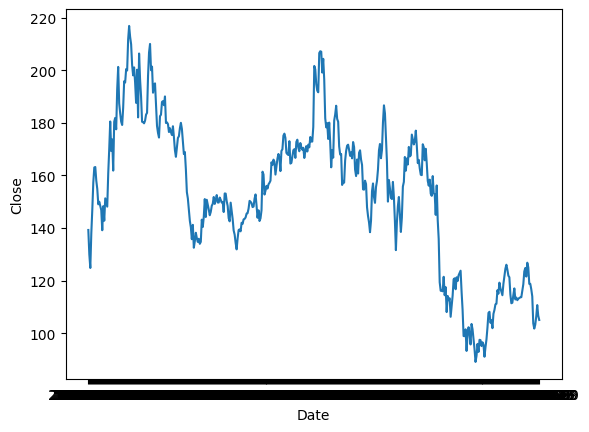

In [26]:
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data = df_abnb, ax=ax)

In [54]:
df_abnb['Date'] = pd.to_datetime(df_abnb['Date'])

In [ ]:
#축라벨회전, 표현방식을 변경,> fomatter를 사용


NameError: name 'ConciseDateFormatter' is not defined

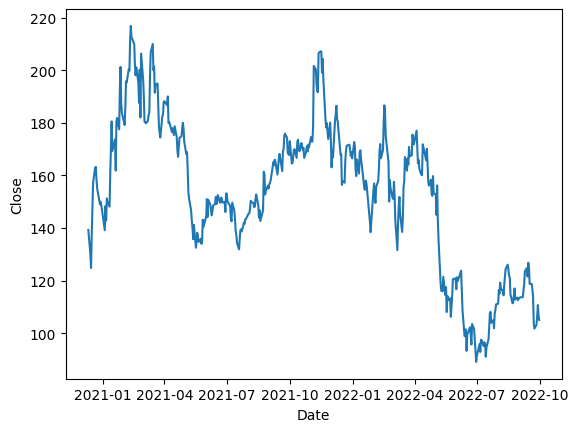

In [ ]:
import matplotlib as mpl

fig, ax = plt.subplots()
sns.lineplot(x='Date', y = 'Close', data=df_abnb, ax=ax)


In [32]:
#plotly line chart 
px.line(data_frame=df_abnb, x='Date', y='Close', width=500, height=400)

In [33]:
fig = px.line(data_frame=df_abnb, x='Date', y='Close', width=500, height=400)
fig.update_xaxes()

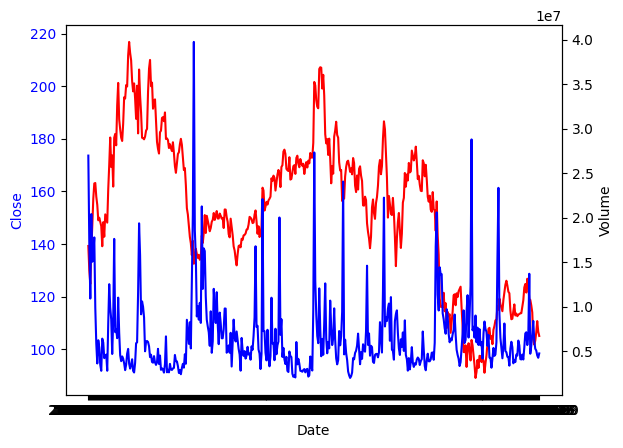

In [52]:
#다중축차트 
#기본차트 x,y + y1+y2 -> 하나의 ax에 그리기
fig, ax = plt.subplots()
ax2=ax.twinx()

sns.lineplot(x='Date', y='Close', data=df_abnb, ax=ax, color='red')
sns.lineplot(x='Date', y='Volume', data=df_abnb, ax=ax2,  color='blue')

#완쪽에 y축 정보설정
ax.tick_params(axis='y', labelcolor='red')
ax.yaxis.label.set_color('red')
#오른쪽에 y축정보
ax.tick_params(axis='y', labelcolor='blue')
ax.yaxis.label.set_color('blue')
#축 날짜포멧지정하기


In [62]:
#3개 축
df_abnb.head()
#최고가 - 최저가 = high Low 변수
df_abnb['High-Low'] = df_abnb['High']-df_abnb['Low']

<Axes: xlabel='Date', ylabel='High-Low'>

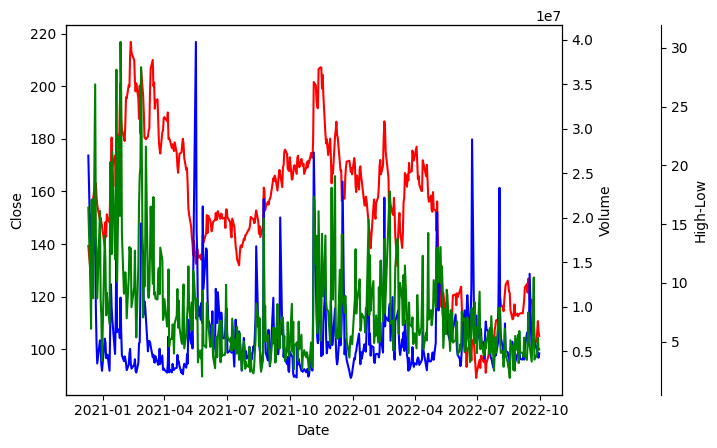

In [72]:
fig, ax =plt.subplots()

ax2=ax.twinx()
ax3=ax.twinx()
ax3.spines.right.set_position(('axes', 1.2)) #현재축에서 0.2 만큼 오른쪽으로 이동
sns.lineplot(x="Date", y="Close", data=df_abnb, ax=ax, color='red')
sns.lineplot(x="Date", y="Volume", data=df_abnb, ax=ax2, color='blue')
sns.lineplot(x="Date", y="High-Low", data=df_abnb, ax=ax3, color='green')

In [91]:
#plotly 로 2중축차트
from plotly.subplots import make_subplots
fig = make_subplots(specs=[[{"secondary_y":True}]]) #2dimension list 로 spec 지정

sub_fig_1 = px.line(df_abnb, x="Date", y='Close')
sub_fig_1.update_traces(line_color='red')
sub_fig_2 = px.line(df_abnb, x="Date", y="Volume")
sub_fig_2.update_traces(line_color='blue')


#레이블 설정
sub_fig_2.update_traces(yaxis='y2')
fig.add_traces(sub_fig_1.data+ sub_fig_2.data)

#레이블 설정
fig.layout.xaxis.title= 'Date'
fig.layout.xaxis.title= 'Close'
fig.layout.xaxis.color= 'red'
fig.layout.xaxis.title= 'volume'
fig.layout.xaxis.color= 'blue'

fig.add_traces(sub_fig_1.data+ sub_fig_2.data)

In [115]:
#3개축 그리기  plotly, gragh
import plotly.graph_objects as go


fig = make_subplots()
fig.add_trace(
      go.Scatter(
    x=df_abnb['Date'], y=df_abnb['Close'], name="Close",
    mode = 'lines', yaxis='y', line={'color':'red'}
  ) # 1번쨰축
)

fig.add_trace(
    go.Scatter(
          x=df_abnb['Date'], y=df_abnb['Volume'], name="Close",
          mode = 'lines', yaxis='y2', line={'color':'blue'}
        
        ) # 2번쨰축
)

fig.add_trace(
    go.Scatter(
        x=df_abnb['Date'], y=df_abnb['High-Low'], name="Close",
        mode = 'lines', yaxis='y3', line={'color':'green'}
        ) # 3번쨰축
)

fig.update_layout(
    
    yaxis=dict(title='Close'),
    yaxis2=dict(title='Volume', position=1, side='right', overlaying='y'),
    yaxis3=dict(title='High-Low', side='right', anchor='x', overlaying='y'),
    xaxis = dict(title='Date', domain=[.1,.85]),
    width=600, height=400 
    
    
)

fig.update_layout()
fig.layout.yaxis.color='red'
fig.layout.yaxis.color='blue'
fig.layout.yaxis.color='green'

fig.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

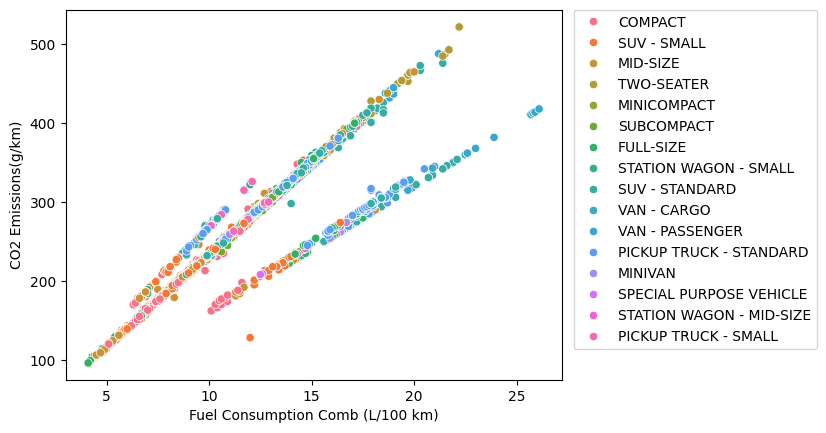

In [124]:
df_co2 = pd.read_csv(
    './data/CO2_Emissions.csv'
)
df_co2.info()



#범례 위치조정하기
fig, ax = plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2, hue='Vehicle Class',
    ax=ax
)

ax.legend(bbox_to_anchor=(1.01, 1.02))

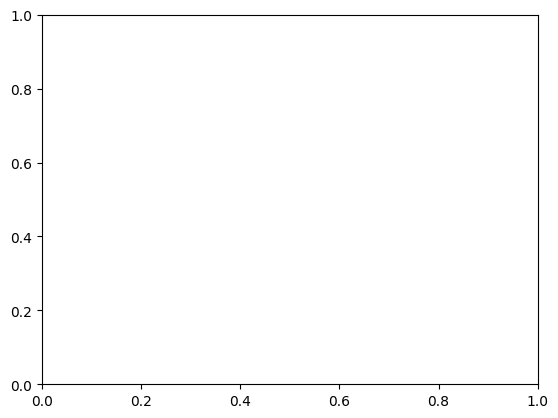

In [144]:
#plotly 로 2중축차트
fig, ax = plt.subplots()

fig = px.scatter(
    df_co2,
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)'
)




fig.update_layout(legend_x=1.2  , legend_y=1)

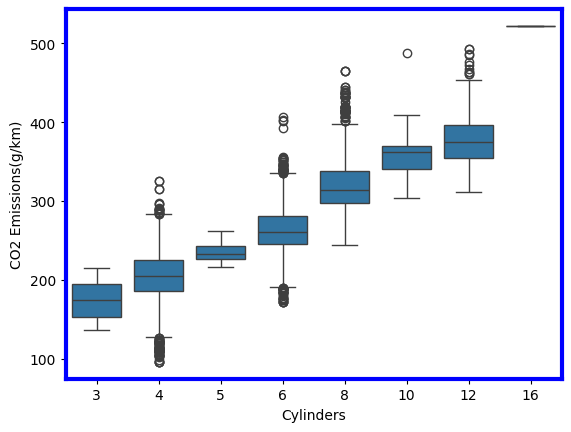

In [149]:
fig, ax = plt.subplots()
sns.boxplot(
    x='Cylinders', y='CO2 Emissions(g/km)',
    data=df_co2, ax=ax
)

spines = ['left', 'right', 'top', 'bottom']
for spin in  spines:
    ax.spines[spin].set_color('blue')
    ax.spines[spin].set_linewidth(3)
ax.spines


In [160]:
# plotly 테두리 강조하기
fig = px.box(
    
)
fig.update_xaxes(showline=True, linecolor ='black', linewidth=4, mirror=True)
fig.update_yaxes() # 매개변수로 가능한것 
fig.show()

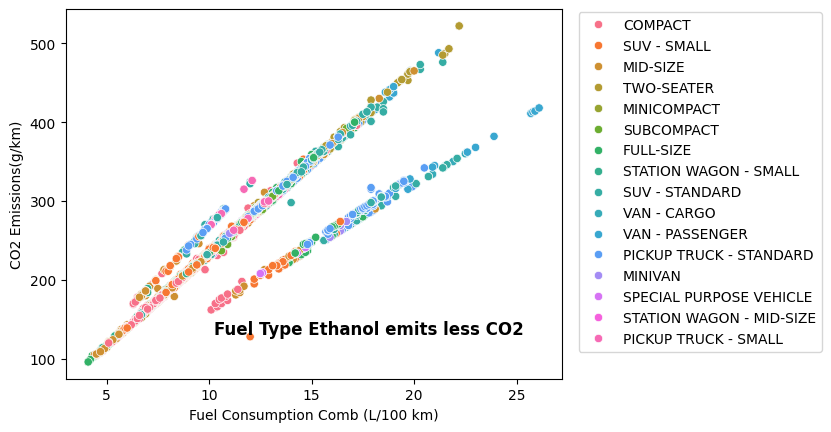

In [184]:
#텍스트로 annote()표시하기

fig, ax =plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2 , hue='Vehicle Class',
    ax=ax
)

ax.text(
    x=0.3, y=0.12, # 상세좌표
    s= 'Fuel Type Ethanol emits less CO2',
    fontdict={'fontsize':12, 'weight':'bold'},
    transform =ax.transAxes
)

ax.legend(bbox_to_anchor=(1.02, 1.01))

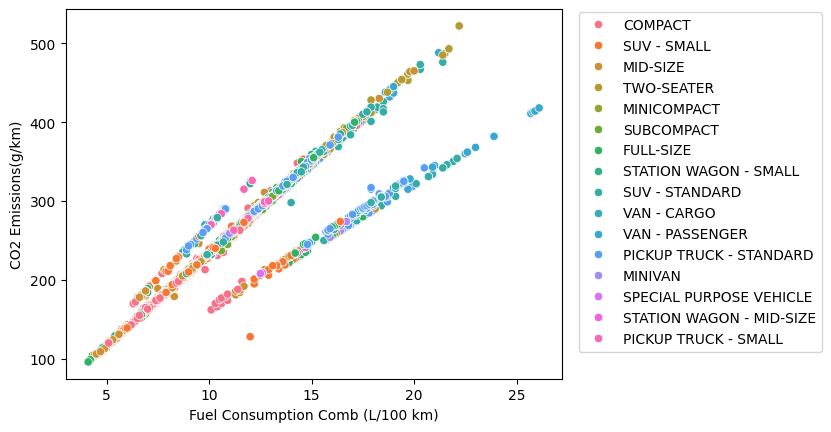

In [ ]:
#텍스트로 annote()표시하기

fig, ax =plt.subplots()
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df_co2 , hue='Vehicle Class',
    ax=ax
)

ax.annotate(
    xy=(0.8,0.7), #절대좌표
    text='ethonal 777',
    xytext=(3,20), 
    arrowprops={'color':'black','width':1}
#s= 'Fuel Type Ethanol emits less CO2',
 #   fontdict={'fontsize':12, 'weight':'bold'},
  #  transform =ax.transAxes
)

ax.legend(bbox_to_anchor=(1.02, 1.01))

In [195]:
#plotly scatter
fig = px.scatter(
    data_frame=df_co2,  x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions(g/km)', color ='Fuel Type', width=800, height=400)
fig.update_layout(legend_x=1.2, legend_y=1)

fig.add_annotation(
    x=20, y=130,
    #x=0.9, y=0.75,
    text='<b>hello</b>',
    #yref='y_domain', 
    #xref='x_domain',
    showarrow=True, arrowhead=2
)

fig.show()

In [196]:
#조건을 이용한 강조하기

In [200]:
df_ins = pd.read_csv(
    './data/product_inspection.csv'
)

In [207]:
df_ins.info()
df_abnb['date'] = pd.to_datetime(df_ins['date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             429 non-null    object 
 1   inspection_step  429 non-null    object 
 2   value            429 non-null    float64
 3   upper_spec       429 non-null    float64
 4   target           429 non-null    float64
 5   lower_spec       429 non-null    float64
dtypes: float64(4), object(2)
memory usage: 20.2+ KB


In [208]:
df_ins_A = df_ins.query("inspection_step=='A'")
df_ins_A

,date,inspection_step,value,upper_spec,target,lower_spec
0,2022-01-01,A,21.2,22.0,21.3,20.6
1,2022-01-02,A,21.7,22.0,21.3,20.6
2,2022-01-03,A,21.4,22.0,21.3,20.6
3,2022-01-04,A,21.5,22.0,21.3,20.6
4,2022-01-05,A,21.5,22.0,21.3,20.6
...,...,...,...,...,...,...
138,2022-05-19,A,21.7,22.0,21.3,20.6
139,2022-05-20,A,21.6,22.0,21.3,20.6
140,2022-05-21,A,21.6,22.0,21.3,20.6
141,2022-05-22,A,21.4,22.0,21.3,20.6


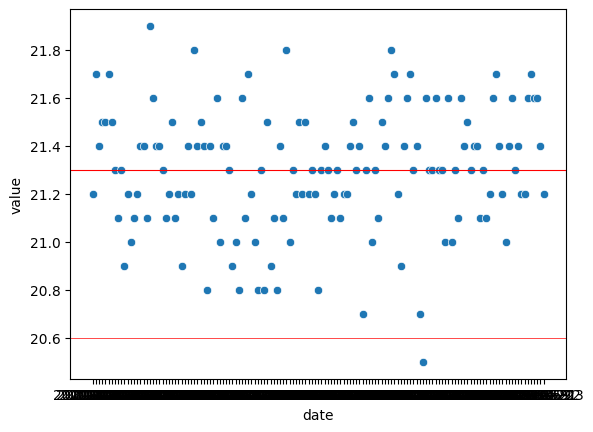

In [214]:
fig, ax =plt.subplots()
sns.scatterplot(
    x='date',
    y='value',
    data=df_ins_A,
    ax=ax
)

ax.axhline(df_ins_A['lower_spec'].iloc[-1], color='red', linewidth=0.5)
ax.axhline(df_ins_A['target'].iloc[-1], color='red', linewidth=0.8)
ax.axhline(df_ins_A['target'].iloc[-1], color='red', linewidth=0.5)

In [218]:
#plotly
fig=px.scatter(df_ins_A, x='date', y='value', width=500, height=400)
#fig.add_hline(df_ins_A['lower_spec'].iloc[-1], line_color='red', linewidth=0.8)

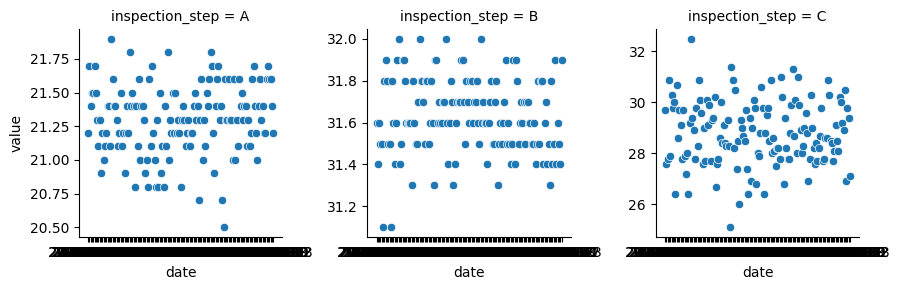

In [ ]:
g = sns.FacetGrid(df_ins, sharex=False, sharey=False, col='inspection_step')
g.map_dataframe(sns.scatterplot, x='date', y='value')


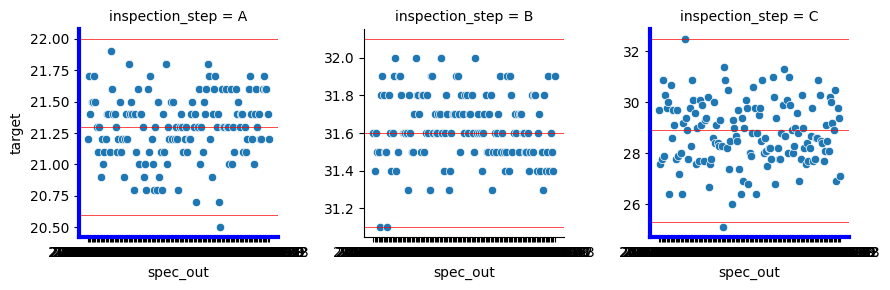

In [245]:
#facetgrid.com() 함수를 위항 함수그리기 
def custom(lower_spec, target, upper_spec, **kws):
    ax = plt.gca()
    # 수평선 그리기
    ax.axhline(lower_spec.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(target.iloc[-1], color='red', linewidth=0.5)
    ax.axhline(upper_spec.iloc[-1], color='red', linewidth=0.5)

def if_spec_out(spec_out, **kws):
    if spec_out.sum() > 0:
        ax=plt.gca()
        spines = ['left','bottom']
        for spine in spines:
            ax.spines[spine].set_color('blue')
            ax.spines[spine].set_linewidth(3)
g = sns.FacetGrid(df_ins, sharex=False, sharey=False, col='inspection_step')
g.map_dataframe(sns.scatterplot, x='date', y='value')
g.map(custom,'lower_spec', 'target', 'upper_spec' )
g.map(if_spec_out, 'spec_out')
    

In [235]:
#Plotly에서의 활용
df = pd.read_csv('./data/product_inspection.csv')
df['date'] = pd.to_datetime(df['date'])

fig = px.scatter(df, x='date', y='value', facet_col='inspection_step')
print(fig.layout.annotations)

#For 문을 이용한 plotly에서의 facet mapping
fig = px.scatter(df, x='date', y='value', facet_col='inspection_step', facet_col_spacing=0.05)

for idx in range(df['inspection_step'].nunique()):
    step = fig.layout.annotations[idx].text.split('=')[1]
    fig.add_hline(
        y=df.query('inspection_step == @step')['lower_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df.query('inspection_step == @step')['upper_spec'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )
    fig.add_hline(
        y=df.query('inspection_step == @step')['target'].iloc[-1],
        line_color='red', line_width=0.5, row=1, col=idx+1
    )

fig.update_yaxes(matches=None)
fig.update_yaxes(showticklabels=True)
fig.show()

(layout.Annotation({
    'font': {},
    'showarrow': False,
    'text': 'inspection_step=A',
    'x': 0.15999999999999998,
    'xanchor': 'center',
    'xref': 'paper',
    'y': 1.0,
    'yanchor': 'bottom',
    'yref': 'paper'
}), layout.Annotation({
    'font': {},
    'showarrow': False,
    'text': 'inspection_step=B',
    'x': 0.49999999999999994,
    'xanchor': 'center',
    'xref': 'paper',
    'y': 1.0,
    'yanchor': 'bottom',
    'yref': 'paper'
}), layout.Annotation({
    'font': {},
    'showarrow': False,
    'text': 'inspection_step=C',
    'x': 0.8399999999999999,
    'xanchor': 'center',
    'xref': 'paper',
    'y': 1.0,
    'yanchor': 'bottom',
    'yref': 'paper'
}))


In [ ]:
#특정 조건에 해당하는 값 찾기
# 각 공정별로 관리스펙에서 벗어난 자재가 있는 그래프 테두리 강조
df_ins['spec_out']= (df_ins['value'] > df_ins['upper_spec']) | (df_ins['value'] < df_ins['lower_spec'])

df_ins


,date,inspection_step,value,upper_spec,target,lower_spec,spec_out
0,2022-01-01,A,21.2,22.0,21.3,20.6,False
1,2022-01-02,A,21.7,22.0,21.3,20.6,False
2,2022-01-03,A,21.4,22.0,21.3,20.6,False
3,2022-01-04,A,21.5,22.0,21.3,20.6,False
4,2022-01-05,A,21.5,22.0,21.3,20.6,False
...,...,...,...,...,...,...,...
424,2022-05-19,C,30.5,32.5,28.9,25.3,False
425,2022-05-20,C,26.9,32.5,28.9,25.3,False
426,2022-05-21,C,29.8,32.5,28.9,25.3,False
427,2022-05-22,C,29.4,32.5,28.9,25.3,False


In [250]:
#기하급수적으로 터지는 y축 값을 반환해서 표현
df_covid = pd.read_csv('./data/Covid19-india.csv')


#색상선택하기

<Axes: xlabel='date', ylabel='confirmed'>

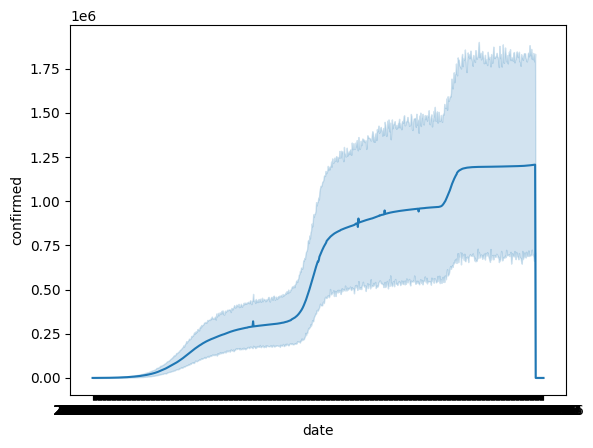

In [252]:
fig, ax = plt.subplots()
sns.lineplot(x='date', y='confirmed', data=df_covid, ax =ax )

In [254]:
df_covid_Mah = df_covid[df_covid.region=='Maharashtra']

In [257]:
df_covid_Mah.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 15857 to 16666
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       810 non-null    object
 1   region     810 non-null    object
 2   confirmed  810 non-null    int64 
 3   active     810 non-null    int64 
 4   cured      810 non-null    int64 
 5   deaths     810 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 44.3+ KB


<Axes: xlabel='date', ylabel='confirmed'>

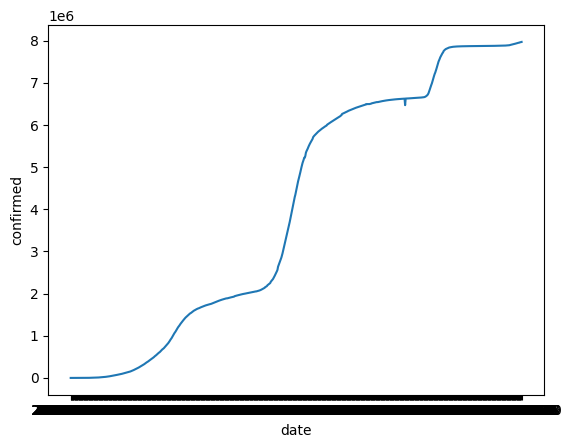

In [258]:
fig, ax = plt.subplots()
sns.lineplot(x='date', y='confirmed', data=df_covid_Mah, ax =ax )

In [260]:
# y값을 로그스케일 log

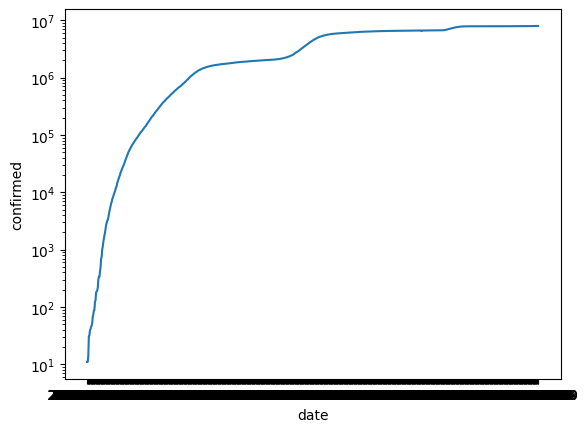

In [261]:
fig, ax = plt.subplots()
sns.lineplot(x='date', y='confirmed', data=df_covid_Mah, ax =ax )
ax.set_yscale('log')

In [265]:
#plotly에서 그리는법

fig  = px.line(
    df_covid_Mah, x='date', y='confirmed', width=500, height=400, log_y=True
)

fig.show()

In [267]:
#seaborn color palette, plotly color

<Axes: xlabel='total_bill', ylabel='tip'>

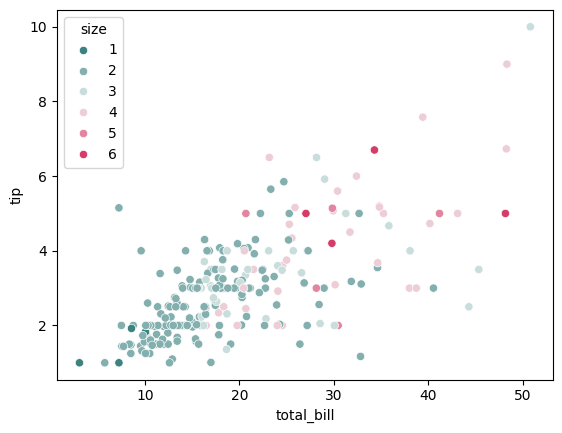

In [276]:
df_tips = sns.load_dataset('tips')

#color = sns.color_palette('light:#006d2c')

color = sns.diverging_palette(550,0, as_cmap=True)

fig, ax  = plt.subplots()

sns.scatterplot(
    x='total_bill', y='tip', data=df_tips, ax=ax,
    hue='size', palette=color
)

In [277]:
#plotly 색상팔레트
# 범주형 :  px.colors.qualitative
# 연속형 :  px.colors.sequential
# 양극형 : px.colors.diverging
# 주기적 데이터: px.colors.cyclical


In [280]:
fig =px.colors.qualitative.swatches()
fig

In [281]:
px.scatter(
    df_tips,   x='total_bill', y='tip',  width=500, height=400,
    color='size', color_continuous_scale='Viridis'
)

In [1]:
df_abnb


NameError: name 'df_abnb' is not defined

In [283]:
#범주형변수 하나골라 그랴보기

px.scatter(
    df_tips,   x='total_bill', y='tip',  width=500, height=400,
    color='size', color_continuous_scale='Viridis'
)